# K-Means Clustering: Theory & Overview

K-Means is one of the most popular **unsupervised machine learning algorithms** used for clustering tasks. The goal is to partition a dataset into **K distinct non-overlapping groups (clusters)** based on feature similarity.

---

### 🔹 How K-Means Works

1. **Initialize**: Choose the number of clusters `k` and initialize `k` centroids (randomly or by a method like K-Means++).
2. **Assignment Step**: Assign each data point to the nearest centroid, forming `k` clusters.
3. **Update Step**: Recalculate the centroids as the mean of the points assigned to each cluster.
4. **Repeat**: Repeat steps 2 and 3 until convergence (centroids no longer move significantly or a max iteration is reached).

---

### 🔹 Objective Function

K-Means minimizes the **Within-Cluster Sum of Squares (WCSS)**, also known as **inertia**:

$$
\text{WCSS} = \sum_{i=1}^{k} \sum_{x_j \in C_i} \|x_j - \mu_i\|^2
$$

Where:
- $ C_i $ is the i-th cluster
- $ \mu_i $ is the centroid of the i-th cluster
- $ x_j $ is a data point in cluster $ C_i $

---

### 🔹 Choosing the Right Number of Clusters (K)

The **Elbow Method** helps determine the optimal number of clusters by:
- Running K-Means with increasing `k`
- Plotting the WCSS for each `k`
- Looking for an "elbow" point where adding more clusters doesn't significantly reduce WCSS

---

### 🔹 Applications

- Customer segmentation
- Image compression
- Market basket analysis
- Pattern recognition

---

K-Means is simple and efficient but assumes spherical clusters and can be sensitive to initialization and outliers.


In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

## Step 1: Load or Generate Dataset
We'll use `make_blobs` to generate a synthetic dataset for demonstration. You can replace this with your dataset.


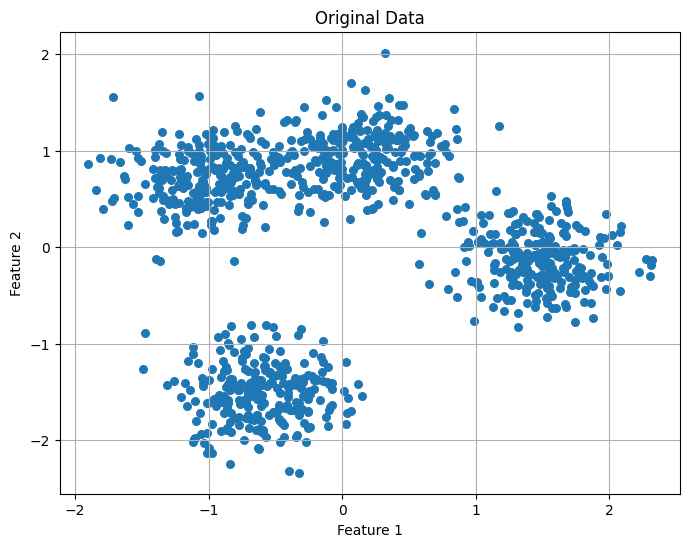

In [67]:
# Generate synthetic dataset
X, y_true = make_blobs(n_samples=1000, centers=4, cluster_std=1.8, random_state=42)


# Standardize data (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualize the raw data
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=30, cmap='viridis')
plt.title("Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()


## Step 2: Elbow Method to Determine Optimal K
We'll run K-Means for a range of `k` values and calculate the Within-Cluster Sum of Squares (WCSS) to find the "elbow point."


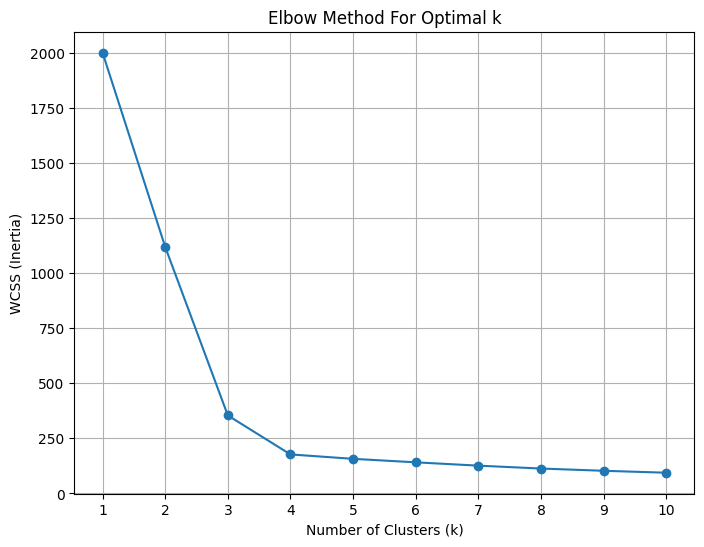

In [68]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # Sum of squared distances to closest cluster center

# Plotting the Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(K_range)
plt.grid(True)
plt.show()


## Step 3: Apply K-Means with Optimal k
From the Elbow plot, choose the k at the "elbow" point. For our synthetic dataset, k=4 seems ideal.


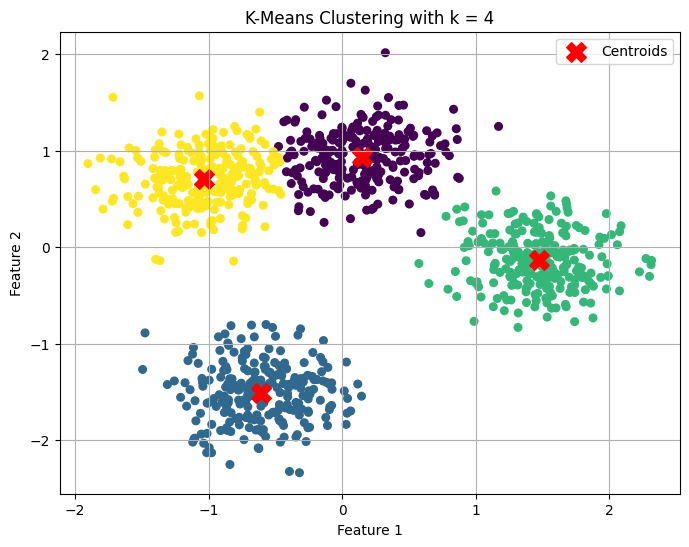

In [69]:
optimal_k = 4  # based on visual inspection of the elbow
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Plot the clustered data
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='viridis', s=30)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', s=200, marker='X', label='Centroids')
plt.title(f"K-Means Clustering with k = {optimal_k}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


## Conclusion
- We successfully applied K-Means clustering to the dataset.
- The Elbow Method helped us find the optimal number of clusters.
- Visualizations clearly show the clusters and their centroids.
